# 01 线性回归：MSE 与梯度下降

目标：把吴恩达课程中的线性回归、代价函数、梯度下降变成你自己的代码。

完成后你应该能回答：

- 线性回归模型的假设函数是什么？
- MSE 代价函数为什么能衡量预测误差？
- 梯度下降每一步在更新什么？
- 学习率过大或过小会发生什么？
- sklearn 的 `LinearRegression` 和手写梯度下降有什么区别？

## 1. 导入依赖

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

## 2. 准备数据

优先读取你已有的 `simple-linear-regression-notebook/data.csv`。

In [13]:
data_path = r"D:\MyDeepLearning\simple-linear-regression-notebook\data.csv"

points = np.genfromtxt(data_path, delimiter=",")

hours_studied = points[:, 0]
test_scores = points[:, 1]

print(points.shape)
points[:5]


(100, 2)


array([[32.50234527, 31.70700585],
       [53.42680403, 68.77759598],
       [61.53035803, 62.5623823 ],
       [47.47563963, 71.54663223],
       [59.81320787, 87.23092513]])

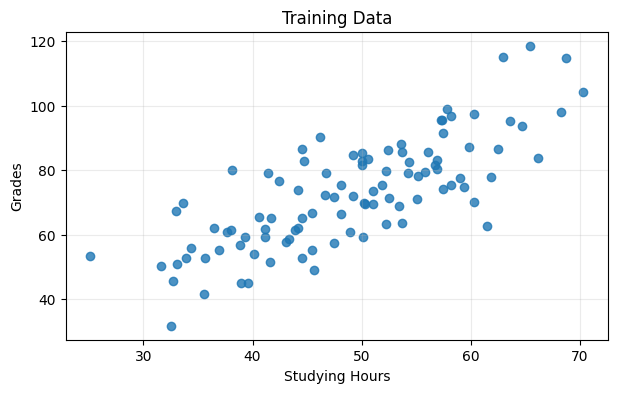

In [14]:
plt.scatter(hours_studied, test_scores, alpha=0.8)
plt.xlabel("Studying Hours")
plt.ylabel("Grades")
plt.title("Training Data")
plt.grid(alpha=0.25)
plt.show()

## 3. 假设函数与代价函数

线性回归假设函数：

$$\hat{y}=wx+b$$

MSE 代价函数：

$$J(w,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})^2$$

In [15]:
def predict(x, w, b):
    return w * x + b


def compute_cost(x, y, w, b):
    y_hat = predict(x, w, b)
    return np.mean((y_hat - y) ** 2)


initial_w = 0.0
initial_b = 0.0

initial_cost = compute_cost(hours_studied, test_scores, initial_w, initial_b)
initial_cost

np.float64(5565.107834483214)

## 4. 手写梯度下降

对 MSE 求偏导：

$$\frac{\partial J}{\partial w}=\frac{2}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})x^{(i)}$$

$$\frac{\partial J}{\partial b}=\frac{2}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})$$

In [16]:
def compute_gradients(x, y, w, b):
    m = len(x)
    y_hat = predict(x, w, b)
    error = y_hat - y

    dw = (2 / m) * np.sum(error * x)
    db = (2 / m) * np.sum(error)
    return dw, db


def gradient_descent(x, y, w, b, learning_rate, epochs):
    history = []

    for epoch in range(epochs):
        cost = compute_cost(x, y, w, b)
        history.append(cost)

        dw, db = compute_gradients(x, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, history

In [17]:
learning_rate = 0.0001
epochs = 2000

w, b, history = gradient_descent(
    x=hours_studied,
    y=test_scores,
    w=initial_w,
    b=initial_b,
    learning_rate=learning_rate,
    epochs=epochs,
)

print(f"w = {w:.4f}")
print(f"b = {b:.4f}")
print(f"final cost = {history[-1]:.4f}")

w = 1.4766
b = 0.1484
final cost = 112.5795


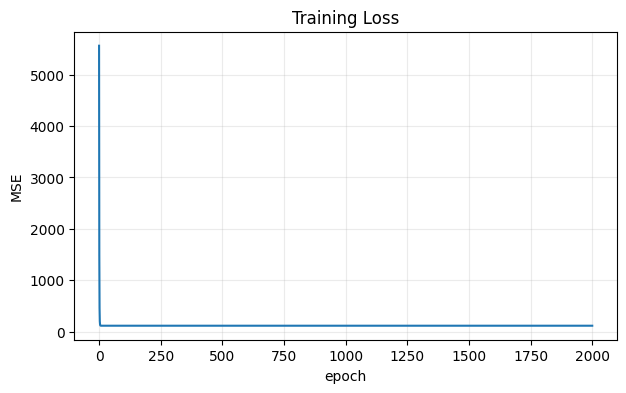

In [18]:
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.grid(alpha=0.25)
plt.show()

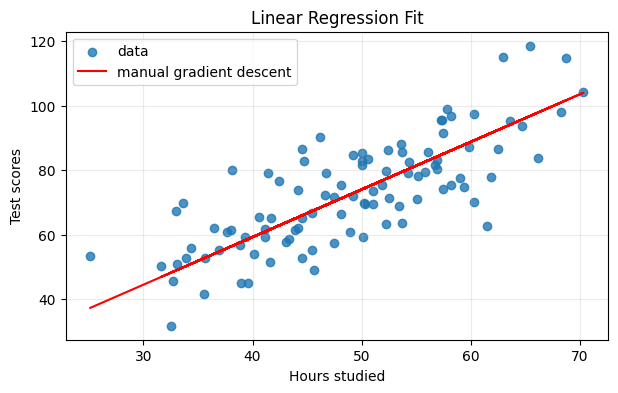

In [19]:
y_pred = predict(hours_studied, w, b)

plt.scatter(hours_studied, test_scores, alpha=0.8, label="data")
plt.plot(hours_studied, y_pred, color="red", label="manual gradient descent")

plt.xlabel("Hours studied")
plt.ylabel("Test scores")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. 调学习率实验

试着修改下面的学习率，观察 loss 曲线：

- 太小：下降很慢。
- 合适：稳定下降。
- 太大：震荡甚至发散。

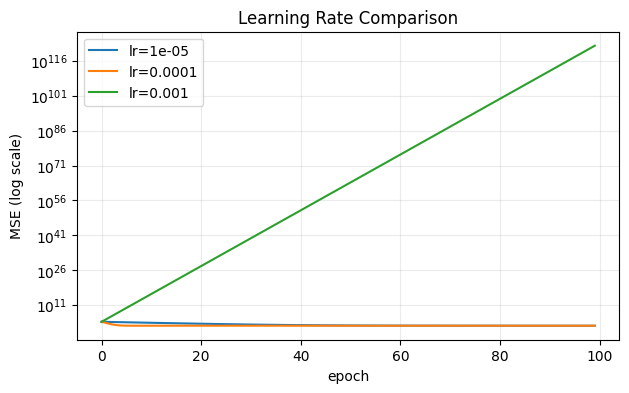

In [20]:
learning_rates = [0.00001, 0.0001, 0.001]

for lr in learning_rates:
    _, _, lr_history = gradient_descent(
        hours_studied, test_scores, 0.0, 0.0, lr, 100
    )
    plt.plot(lr_history, label=f"lr={lr}")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. 对比 sklearn

In [21]:
model = LinearRegression()
model.fit(hours_studied.reshape(-1, 1), test_scores)

sklearn_pred = model.predict(hours_studied.reshape(-1, 1))
sklearn_mse = mean_squared_error(test_scores, sklearn_pred)

print(f"manual w:  {w:.4f}, manual b:  {b:.4f}, manual mse:  {history[-1]:.4f}")
print(f"sklearn w: {model.coef_[0]:.4f}, sklearn b: {model.intercept_:.4f}, sklearn mse: {sklearn_mse:.4f}")


manual w:  1.4766, manual b:  0.1484, manual mse:  112.5795
sklearn w: 1.3224, sklearn b: 7.9910, sklearn mse: 110.2574


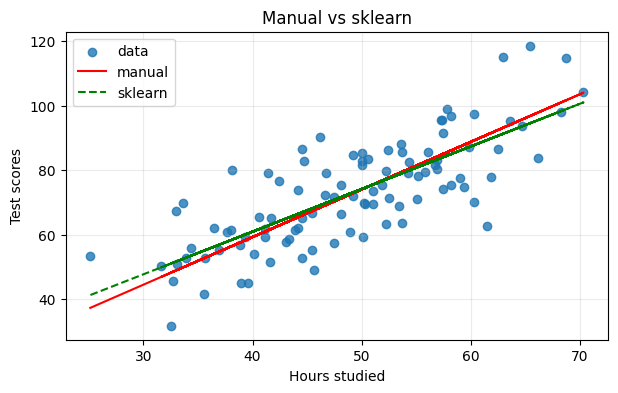

In [22]:
plt.scatter(hours_studied, test_scores, alpha=0.8, label="data")
plt.plot(hours_studied, y_pred, color="red", label="manual")
plt.plot(hours_studied, sklearn_pred, color="green", linestyle="--", label="sklearn")

plt.xlabel("Hours studied")
plt.ylabel("Test scores")
plt.title("Manual vs sklearn")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. 总结

请你自己补充下面几项：

1. 本次实验中，学习率改大后发生了什么？
2. 手写梯度下降和 sklearn 的结果是否完全一样？为什么？
3. 如果 loss 不下降，你会优先检查哪些地方？
4. 线性回归有哪些明显局限？

我的总结：

我的总结：

1. 本次实验中，学习率变大后，loss 不一定下降得更快。当学习率从 `0.0001` 增加到 `0.001` 时，MSE 迅速变得极大，说明参数更新步子太大，梯度下降发散了。学习率太小会收敛很慢，学习率太大则会越过最优点并越来越偏。

2. 手写梯度下降和 sklearn 的结果不完全一样。sklearn 的 `LinearRegression` 通常直接求最小 MSE 的最优解，而我手写的梯度下降是一步一步迭代逼近最优解。如果 epoch 不够、学习率不合适，或者特征没有缩放，手写结果就可能还没有收敛到 sklearn 的结果。

3. 如果 loss 不下降，我会优先检查学习率是否过大或过小、梯度公式和更新方向是否写反、`x` 和 `y` 是否对应正确、训练轮数是否太少、数据尺度是否需要标准化，以及代码中是否出现了 NaN 或异常大的数值。

4. 线性回归的明显局限是它只能拟合线性关系。如果数据本身是非线性的，简单直线模型效果会差。它也对异常值比较敏感，因为 MSE 会放大大误差。另外，线性回归输出的是连续数值，不适合直接处理分类问题。
